# DATA606 - Project 2

#### Name - Swattik Maiti
#### UID - 121079367
#### Email - swat0507@umd.edu

## 1. Importing Packages and libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error


%matplotlib inline

In [2]:
# Set options to display all rows
pd.set_option('display.max_rows', None)

# Set options to display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
warnings.filterwarnings("ignore")

## 2. Loading the datasets

In [3]:
# Load user, rating, and book metadata into pandas DataFrames
user_df = pd.read_csv('../data/Users.csv', index_col="User-ID")
rating_df = pd.read_csv('../data/Ratings.csv')
books_df = pd.read_csv('../data/Books.csv',index_col="ISBN")

In [4]:
user_df.head()

,Location,Age
User-ID,,
1,"nyc, new york, usa",NaN
2,"stockton, california, usa",18.0
3,"moscow, yukon territory, russia",NaN
4,"porto, v.n.gaia, portugal",17.0
5,"farnborough, hants, united kingdom",NaN


In [5]:
rating_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
books_df.head()

,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
ISBN,,,,,,,
0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


## 3. EDA and Data Preprocessing

### 3.1 Basic Exploratory Data Analysis

In [7]:

def basic_eda(df):

    print("\n ------------------ INFO ------------------ ")
    print(df.info())

    print("\n ------------------ DESCRIBE ------------------ ")
    print(df.describe())

    print("\n ------------------ SHAPE ------------------ ")
    print(df.shape)

    print("\n ------------------ NULL VALUES ------------------ ")
    print(df.isnull().sum())

    print("\n ------------------ DUPLICATE VALUES ------------------ ")
    print(df.duplicated().sum())


In [8]:
basic_eda(user_df)


 ------------------ INFO ------------------ 
<class 'pandas.core.frame.DataFrame'>
Index: 278858 entries, 1 to 278858
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Location  278858 non-null  object 
 1   Age       168096 non-null  float64
dtypes: float64(1), object(1)
memory usage: 6.4+ MB
None

 ------------------ DESCRIBE ------------------ 
                 Age
count  168096.000000
mean       34.751434
std        14.428097
min         0.000000
25%        24.000000
50%        32.000000
75%        44.000000
max       244.000000

 ------------------ SHAPE ------------------ 
(278858, 2)

 ------------------ NULL VALUES ------------------ 
Location         0
Age         110762
dtype: int64

 ------------------ DUPLICATE VALUES ------------------ 
139227



#### **Key Observations**
- **Significant Missing Values in Age**
A large portion of the users (~40%) have missing age values, which could reduce the reliability of any age-based analysis unless handled carefully (e.g., via imputation or exclusion).

- **Presence of Invalid or Outlier Ages**
Some entries have clearly invalid ages (like 0 and 244), suggesting the need for filtering or cleaning to retain only plausible user ages (e.g., 5–100).

- **Nearly Half the Data is Duplicated**
The presence of ~139k duplicate records may indicate redundant user profiles or data collection issues; these should be removed to prevent data skew.

- **Location Field is Fully Populated**
The Location column has no missing values and can be a good candidate for geographic grouping or user segmentation if parsed into components (e.g., country, city).


In [9]:
basic_eda(rating_df)


 ------------------ INFO ------------------ 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
None

 ------------------ DESCRIBE ------------------ 
            User-ID   Book-Rating
count  1.149780e+06  1.149780e+06
mean   1.403864e+05  2.866950e+00
std    8.056228e+04  3.854184e+00
min    2.000000e+00  0.000000e+00
25%    7.034500e+04  0.000000e+00
50%    1.410100e+05  0.000000e+00
75%    2.110280e+05  7.000000e+00
max    2.788540e+05  1.000000e+01

 ------------------ SHAPE ------------------ 
(1149780, 3)

 ------------------ NULL VALUES ------------------ 
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

 ------------------ DUPLICATE VALUES 


#### **Key Observations**

- **No Missing or Duplicate Records**  
  All entries are complete with no null values or duplicates, which is ideal for building a recommendation engine without initial cleanup.

- **Rating Values Include Unrated Entries**  
  A large proportion of entries have a `Book-Rating` of **0**, which represents **missing or implicit ratings**. These may need to be excluded or handled differently depending on your modeling strategy.

- **Highly Skewed Rating Distribution**  
  The **median rating is 0**, and the mean is low (~2.87), suggesting the majority of books are not rated or are rated poorly, which could bias model training if not balanced.

- **Rich Dataset for Collaborative Filtering**  
  With over **1.14 million user-book rating pairs**, this dataset provides a strong foundation for collaborative filtering, though sparsity in actual ratings may still be an issue.

- **User-ID Range Suggests Diverse Participation**  
  User-IDs span from 2 to over 278,000, indicating a broad user base. However, further filtering may be required to focus on users with meaningful activity (e.g., who rated >5 books).



In [10]:
basic_eda(books_df)


 ------------------ INFO ------------------ 
<class 'pandas.core.frame.DataFrame'>
Index: 271360 entries, 0195153448 to 0767409752
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Book-Title           271360 non-null  object
 1   Book-Author          271358 non-null  object
 2   Year-Of-Publication  271360 non-null  object
 3   Publisher            271358 non-null  object
 4   Image-URL-S          271360 non-null  object
 5   Image-URL-M          271360 non-null  object
 6   Image-URL-L          271357 non-null  object
dtypes: object(7)
memory usage: 16.6+ MB
None

 ------------------ DESCRIBE ------------------ 
            Book-Title      Book-Author  Year-Of-Publication  Publisher  \
count           271360           271358               271360     271358   
unique          242135           102022                  202      16807   
top     Selected Poems  Agatha Christie                 2002  Har


#### **Key Observations**

- **Minimal Missing Values**  
  Only a few records have missing entries in `Book-Author`, `Publisher`, and `Image-URL-L` (fewer than 5 in total), which can be easily handled with simple imputation or removal.

- **High Cardinality in Titles and Authors**  
  With over **242,000 unique book titles** and **102,000 unique authors**, the dataset is extremely sparse on a per-book basis, which may reduce the effectiveness of item-item filtering unless filtered or clustered.

- **Repetitive Image URLs**  
  Although most image URLs are unique, some occur more than once — suggesting possible duplicates or shared cover art among different editions or ISBNs.

- **Duplicate Book Entries**  
  About **195 duplicate records** exist, likely due to ISBNs tied to the same book but with minor differences (e.g., alternate editions or typos). These should be checked to ensure accurate item mapping.

- **Dominance of Certain Authors and Publishers**  
  Some authors like *Agatha Christie* and publishers like *Harlequin* appear disproportionately, possibly skewing recommendations if popularity bias isn't addressed.


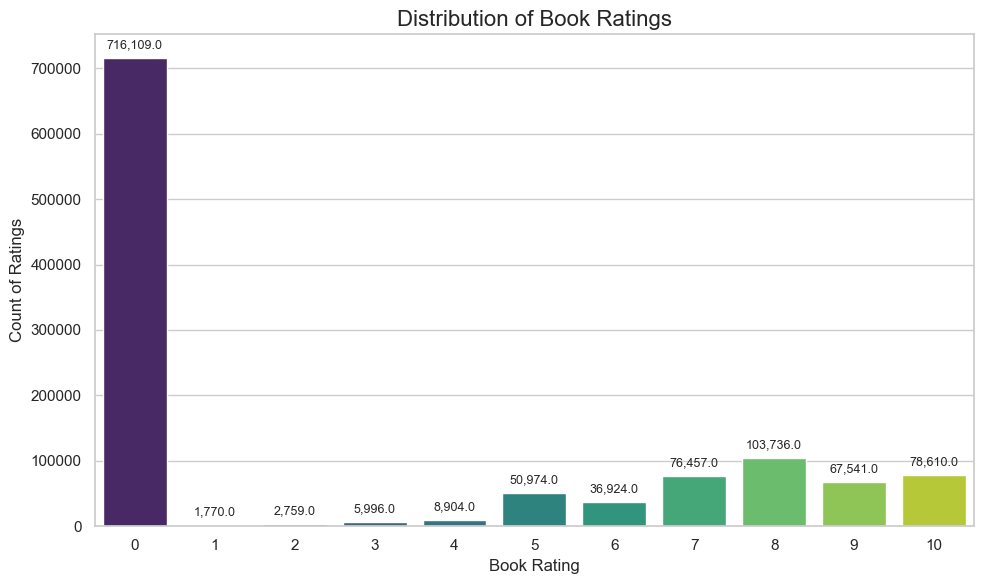

In [11]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Book-Rating', data=rating_df, palette='viridis')

# Add counts above bars
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{height:,}',  
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.title('Distribution of Book Ratings', fontsize=16)
plt.xlabel('Book Rating', fontsize=12)
plt.ylabel('Count of Ratings', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Re confirming the fact that most books are not rated and the data is highly skewed. 

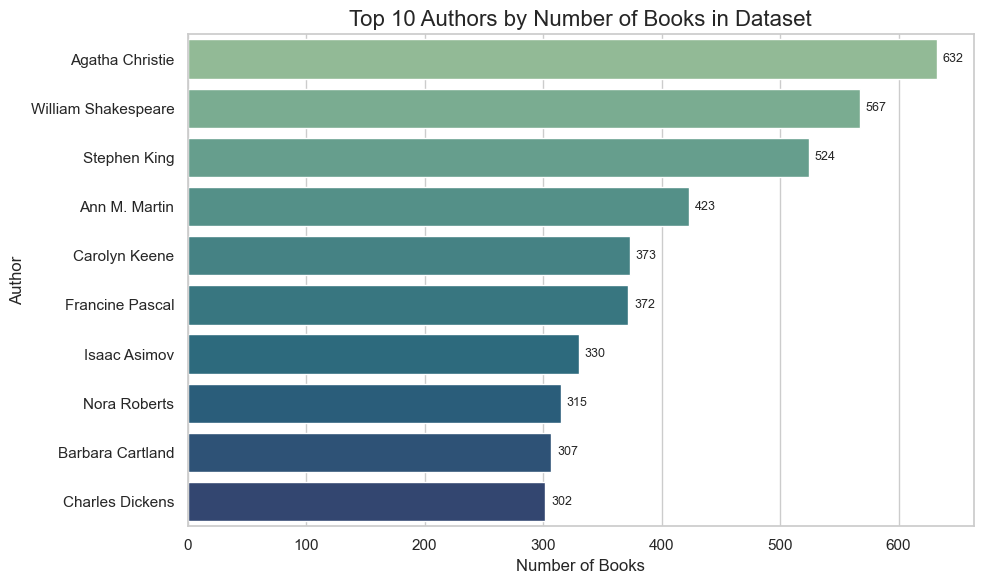

In [12]:
# Count top 10 authors
top_authors = books_df['Book-Author'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_authors.values, y=top_authors.index, palette="crest")

# Add counts to bars
for i, count in enumerate(top_authors.values):
    ax.text(count + 5, i, f'{count:,}', va='center', fontsize=9)

# Titles and labels
plt.title('Top 10 Authors by Number of Books in Dataset', fontsize=16)
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

### 3.2 Data Cleaning

In [13]:
# Filter the Ratings Data

# Drop implicit feedback (Book-Rating == 0)
filtered_ratings = rating_df[rating_df['Book-Rating'] > 0].copy()

#### Filtering Active Users & Popular Books Before Train-Test Split
Removes Sparse Users/Books
Users who’ve rated only 1–2 books (or books rated by very few people) offer too little data to compute meaningful similarity. These rows introduce noise.

Improves Recommendation Quality
Collaborative filtering depends on overlap in ratings — filtering ensures a denser core of users and books where such overlap is more likely.

Prevents Cold Start Issues in Test Set
Ensures we don’t end up with test cases where we can't make predictions because no one has rated the book or the user has rated too little.

In [14]:
def filter_active_users_and_books(ratings, min_user_ratings=5, min_book_ratings=5):
    print(f"Filtering data. Initial shape: {ratings.shape}")
    while True:
        initial_rows = ratings.shape[0]
        user_counts = ratings['User-ID'].value_counts()
        book_counts = ratings['ISBN'].value_counts()

        # Get valid IDs
        valid_users = user_counts[user_counts >= min_user_ratings].index
        valid_books = book_counts[book_counts >= min_book_ratings].index

        # Filter the DataFrame
        ratings = ratings[ratings['User-ID'].isin(valid_users) & ratings['ISBN'].isin(valid_books)]

        current_rows = ratings.shape[0]
        print(f"Filtering iteration complete. Shape now: {ratings.shape}")

        # Stop if no change
        if current_rows == initial_rows or current_rows == 0:
            break

    print(f"Final shape after filtering: {ratings.shape}")
    if current_rows == 0:
        print("Warning: Filtering removed all data.")
    return ratings

In [15]:
filtered_ratings = filter_active_users_and_books(filtered_ratings)

Filtering data. Initial shape: (433671, 3)
Filtering iteration complete. Shape now: (152280, 3)
Filtering iteration complete. Shape now: (128739, 3)
Filtering iteration complete. Shape now: (121829, 3)
Filtering iteration complete. Shape now: (119899, 3)
Filtering iteration complete. Shape now: (119192, 3)
Filtering iteration complete. Shape now: (118981, 3)
Filtering iteration complete. Shape now: (118878, 3)
Filtering iteration complete. Shape now: (118832, 3)
Filtering iteration complete. Shape now: (118796, 3)
Filtering iteration complete. Shape now: (118784, 3)
Filtering iteration complete. Shape now: (118772, 3)
Filtering iteration complete. Shape now: (118752, 3)
Filtering iteration complete. Shape now: (118732, 3)
Filtering iteration complete. Shape now: (118717, 3)
Filtering iteration complete. Shape now: (118699, 3)
Filtering iteration complete. Shape now: (118680, 3)
Filtering iteration complete. Shape now: (118672, 3)
Filtering iteration complete. Shape now: (118668, 3)
Fil

### 3.3 Splitting the dat into train and test set 

In [16]:
# Random 75/25 split on (User-ID, ISBN) rating pairs
train_df, test_df = train_test_split(
    filtered_ratings,
    test_size=0.25,
    random_state=42
)

# Ensure all test users are present in train set
test_df = test_df[test_df['User-ID'].isin(train_df['User-ID'])].copy()

# Reset index for convenience
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

# Sanity check
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (89001, 3)
Test shape: (29662, 3)


Note :
- In User-User CF, predictions for a target user are made by finding similar users (neighbors) based on their past ratings.
If a user exists only in the test set (i.e., not seen in training), the model has no ratings or similarity information to make predictions.
Thus I am ensuring all test users are present in train set which basically prevents the cold start problem

## 4. User-User Collaborative Filtering

### 4.1 Encode User and Book IDs to Integer Indices
Collaborative filtering works on matrices where rows = users, columns = items (books).

Matrix-building functions like csr_matrix require numeric indices, not raw strings or large user IDs like 276729.


In [17]:
# Convert User-ID and ISBN to integer indices
user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

train_df['user_idx'] = user_encoder.fit_transform(train_df['User-ID'])
train_df['book_idx'] = book_encoder.fit_transform(train_df['ISBN'])

# Filter Test Set to Avoid Cold-Start Users and Books
test_df = test_df[
    test_df['User-ID'].isin(train_df['User-ID']) &
    test_df['ISBN'].isin(train_df['ISBN'])
].copy()

# Map same encoders to test set
test_df['user_idx'] = user_encoder.transform(test_df['User-ID'])
test_df['book_idx'] = book_encoder.transform(test_df['ISBN'])

n_users = train_df['user_idx'].nunique()
n_books = train_df['book_idx'].nunique()


### 4.2 Create a Sparse User-Item Matrix

Most users haven’t rated most books, so we use a sparse matrix to efficiently store only the non-zero entries (ratings).

In [18]:
# Create sparse matrix [n_users x n_books] with ratings as values
sparse_user_item_train = csr_matrix(
    (train_df['Book-Rating'].values, (train_df['user_idx'], train_df['book_idx'])),
    shape=(n_users, n_books)
)

In [19]:
matrix_size = sparse_user_item_train.shape[0] * sparse_user_item_train.shape[1]
non_zero_elements = sparse_user_item_train.nnz
sparsity = 100 * (1.0 - non_zero_elements / matrix_size)

print(f"Sparse matrix shape: {sparse_user_item_train.shape}")
print(f"Matrix sparsity: {sparsity:.4f}%")

Sparse matrix shape: (7024, 9429)
Matrix sparsity: 99.8656%


## 5. Similarity, Prediction, and Evaluation


### 5.1 Computing the User Similarity Matrix
Compute cosine similarity between users based on their rating vectors. The cosine similarity measures how similar two users are based on their rating patterns. Each user is represented as a vector in the user-item matrix, and the similarity value ranges from 0 (no similarity) to 1 (identical preferences). This similarity matrix is the fundamental step for finding “neighbors” in collaborative filtering

In [20]:
# Compute user-user similarity
user_similarity_matrix = cosine_similarity(sparse_user_item_train, dense_output=True)

# Clean NaN or Inf values
user_similarity_matrix = np.nan_to_num(user_similarity_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print(f"User similarity matrix computed. Shape: {user_similarity_matrix.shape}")

# Step 3: Sample preview
print("\nSample of similarity matrix:")
sample_users = user_encoder.classes_[:10]  # original User-IDs
print(pd.DataFrame(user_similarity_matrix[:10, :10], index=sample_users, columns=sample_users))

User similarity matrix computed. Shape: (7024, 7024)

Sample of similarity matrix:
     99   114       243       244  254  388  446  503  505  507
99   1.0  0.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  0.0
114  0.0  1.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  0.0
243  0.0  0.0  1.000000  0.138379  0.0  0.0  0.0  0.0  0.0  0.0
244  0.0  0.0  0.138379  1.000000  0.0  0.0  0.0  0.0  0.0  0.0
254  0.0  0.0  0.000000  0.000000  1.0  0.0  0.0  0.0  0.0  0.0
388  0.0  0.0  0.000000  0.000000  0.0  1.0  0.0  0.0  0.0  0.0
446  0.0  0.0  0.000000  0.000000  0.0  0.0  1.0  0.0  0.0  0.0
503  0.0  0.0  0.000000  0.000000  0.0  0.0  0.0  1.0  0.0  0.0
505  0.0  0.0  0.000000  0.000000  0.0  0.0  0.0  0.0  1.0  0.0
507  0.0  0.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  1.0


In [21]:
# user_similarity_matrix.head()

### 5.2 Predicting Ratings Using User-User Collaborative Filtering

This function predicts how a user might rate a book by looking at how similar users have rated it. It works by:

- Finding users who rated the same book.

- Selecting the top k most similar users based on cosine similarity.

- Computing a weighted average of their ratings using similarity scores as weights.

- Falling back to a global average rating if no similar users are found.

The result is a personalized prediction, clipped to the valid range [1, 10].

In [22]:
def predict_rating_user_user(user_idx, book_idx, sparse_matrix, similarity_matrix, k=10, global_fallback=7.5):
    """
    Predict the rating for a user-book pair using User-User Collaborative Filtering.
    
    Args:
        user_idx: int, index of the target user
        book_idx: int, index of the target book
        sparse_matrix: csr_matrix, user-item training matrix
        similarity_matrix: ndarray, precomputed user-user similarity matrix
        k: int, number of top neighbors to consider
        global_fallback: float, fallback rating if prediction isn't possible
        
    Returns:
        float, predicted rating
    """
    # Get similarity vector for the target user
    similarities = similarity_matrix[user_idx].copy()
    similarities[user_idx] = 0  # remove self-similarity

    # Get ratings for the target book
    book_ratings = sparse_matrix[:, book_idx].toarray().flatten()
    rated_by_users = np.where(book_ratings > 0)[0]

    # No user has rated this book case
    if len(rated_by_users) == 0:
        return global_fallback  

    # Get similarities and ratings for users who rated this book
    sim_scores = similarities[rated_by_users]
    ratings = book_ratings[rated_by_users]

    # Select top-k most similar users
    if len(sim_scores) > k:
        top_k_idx = np.argsort(sim_scores)[-k:] 
        sim_scores = sim_scores[top_k_idx]
        ratings = ratings[top_k_idx]

    # Filter out non-positive similarities
    valid_mask = sim_scores > 0
    if not np.any(valid_mask):
        return global_fallback

    sim_scores = sim_scores[valid_mask]
    ratings = ratings[valid_mask]

    # Compute weighted average
    prediction = np.dot(sim_scores, ratings) / np.sum(sim_scores)
    prediction = np.clip(prediction, 1, 10)  

    return prediction


In [24]:
# Store predictions here
predictions = []

# Loop through each test row and predict
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    pred = predict_rating_user_user(
        user_idx=row.user_idx,
        book_idx=row.book_idx,
        sparse_matrix=sparse_user_item_train,
        similarity_matrix=user_similarity_matrix,
        k=10  # You can vary this
    )
    predictions.append(pred)

# Add predictions to the test DataFrame
test_df['predicted_rating'] = predictions

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:03<00:00, 8838.65it/s]


In [26]:
mad = mean_absolute_error(test_df['Book-Rating'], test_df['predicted_rating'])
print(f"Mean Absolute Difference (MAD) @ k=10: {mad:.4f}")

Mean Absolute Difference (MAD) @ k=10: 1.5340


### 5.3 **Varying K**

Now we'll use the calculate_mad_parallel function to evaluate our model's performance with different neighborhood sizes (k). We'll test the values required by the assignment: 5, 10, 15, 20, 50, and 100.

In [27]:
ks = [5, 10, 15, 20, 50, 100]
mad_scores = {}

for k in ks:
    predictions = [
        predict_rating_user_user(
            user_idx=row.user_idx,
            book_idx=row.book_idx,
            sparse_matrix=sparse_user_item_train,
            similarity_matrix=user_similarity_matrix,
            k=k
        )
        for row in tqdm(test_df.itertuples(), total=len(test_df))
    ]
    mad = mean_absolute_error(test_df['Book-Rating'], predictions)
    mad_scores[k] = mad
    print(f"MAD @ k={k}: {mad:.4f}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:03<00:00, 9438.20it/s]


MAD @ k=5: 1.5485


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:02<00:00, 10615.10it/s]


MAD @ k=10: 1.5340


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:02<00:00, 10886.37it/s]


...

MAD @ k=20: 1.5312


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:02<00:00, 10480.35it/s]


MAD @ k=50: 1.5312


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29647/29647 [00:03<00:00, 9651.26it/s]

MAD @ k=100: 1.5312



---

### **Observations & Inferences from Top-k Neighborhood Size Experiment**

* **MAD decreases** as `k` increases from 5 to 20, indicating that incorporating more similar users initially improves prediction accuracy.
* After `k = 20`, the **MAD plateaus at \~1.5312**, showing **diminishing returns** from adding more neighbors.
* The minimal performance gain beyond `k = 20` suggests that including too many neighbors may add noise or redundant information.
* **Optimal neighborhood size** lies between `k = 10` and `k = 20` for a good balance between **accuracy and computational efficiency**.
* Very small `k` (like 5) leads to slightly higher MAD, likely due to limited input from similar users.



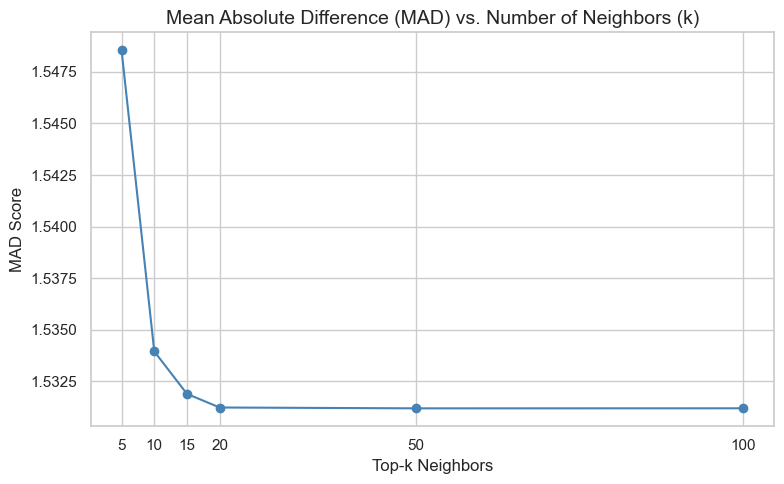

In [28]:
k_values = sorted(mad_scores.keys())
mad_values = [mad_scores[k] for k in k_values]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, mad_values, marker='o', linestyle='-', color='steelblue')
plt.title('Mean Absolute Difference (MAD) vs. Number of Neighbors (k)', fontsize=14)
plt.xlabel('Top-k Neighbors', fontsize=12)
plt.ylabel('MAD Score', fontsize=12)
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()


### 5.4  **Evaluating Performance Across Varying Training Ratios**

To understand how the amount of training data affects the performance of **User-User Collaborative Filtering**, we evaluate the model using different train-test splits.

We vary the **training set size from 60% to 90%** (in 5% increments) and measure prediction accuracy using **Mean Absolute Difference (MAD)**.

This experiment helps us answer:

* How much training data is needed to make reliable predictions?
* Does increasing the training size always improve performance?
* At what point does adding more data stop yielding meaningful gains?

By analyzing MAD scores across these ratios, we gain insights into the **data-efficiency and scalability** of the collaborative filtering model.



In [29]:
train_ratios = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
mad_per_ratio = {}
k_fixed = 10  # Fixed neighborhood size for fair comparison

for ratio in train_ratios:
    print(f"\n=== Train ratio: {int(ratio*100)}% ===")
    
    # Train-test split
    train_df, test_df = train_test_split(
        filtered_ratings,
        test_size=(1 - ratio),
        random_state=42
    )

    # Remove cold-start users/books from test set
    test_df = test_df[
        test_df['User-ID'].isin(train_df['User-ID']) &
        test_df['ISBN'].isin(train_df['ISBN'])
    ].copy()

    # Label encode users and books
    user_encoder = LabelEncoder()
    book_encoder = LabelEncoder()

    train_df['user_idx'] = user_encoder.fit_transform(train_df['User-ID'])
    train_df['book_idx'] = book_encoder.fit_transform(train_df['ISBN'])

    test_df['user_idx'] = user_encoder.transform(test_df['User-ID'])
    test_df['book_idx'] = book_encoder.transform(test_df['ISBN'])

    # Create sparse user-item matrix
    n_users = train_df['user_idx'].nunique()
    n_books = train_df['book_idx'].nunique()

    sparse_matrix = csr_matrix(
        (train_df['Book-Rating'], (train_df['user_idx'], train_df['book_idx'])),
        shape=(n_users, n_books)
    )

    # Compute user-user cosine similarity
    similarity_matrix = cosine_similarity(sparse_matrix, dense_output=True)
    similarity_matrix = np.nan_to_num(similarity_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    # Predict ratings for test set
    predictions = []
    for row in test_df.itertuples():
        pred = predict_rating_user_user(
            user_idx=row.user_idx,
            book_idx=row.book_idx,
            sparse_matrix=sparse_matrix,
            similarity_matrix=similarity_matrix,
            k=k_fixed
        )
        predictions.append(pred)

    # Compute MAD
    mad = mean_absolute_error(test_df['Book-Rating'], predictions)
    mad_per_ratio[int(ratio * 100)] = mad
    print(f"MAD @ train_ratio={int(ratio * 100)}%: {mad:.4f}")


=== Train ratio: 60% ===
MAD @ train_ratio=60%: 1.5580

=== Train ratio: 65% ===
MAD @ train_ratio=65%: 1.5486

=== Train ratio: 70% ===
MAD @ train_ratio=70%: 1.5410

=== Train ratio: 75% ===
MAD @ train_ratio=75%: 1.5340

=== Train ratio: 80% ===
MAD @ train_ratio=80%: 1.5287

=== Train ratio: 85% ===
MAD @ train_ratio=85%: 1.5238

=== Train ratio: 90% ===
MAD @ train_ratio=90%: 1.5140


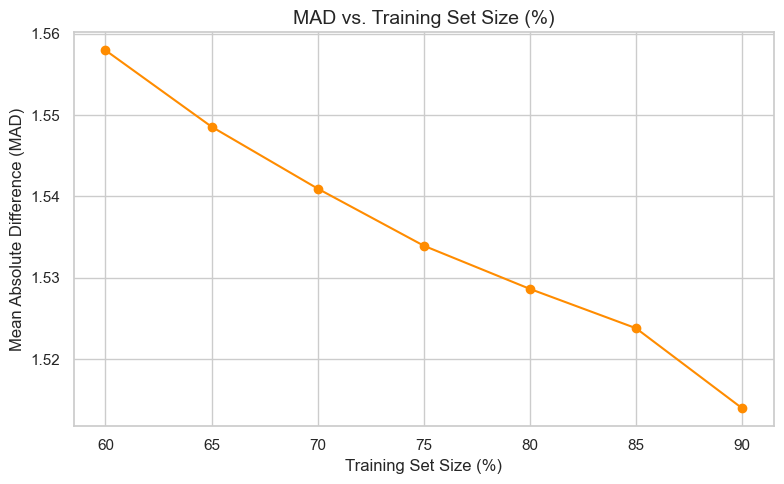

In [30]:
# Sort ratios for consistent plotting
ratios = sorted(mad_per_ratio.keys())
mad_values = [mad_per_ratio[r] for r in ratios]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ratios, mad_values, marker='o', linestyle='-', color='darkorange')
plt.title('MAD vs. Training Set Size (%)', fontsize=14)
plt.xlabel('Training Set Size (%)', fontsize=12)
plt.ylabel('Mean Absolute Difference (MAD)', fontsize=12)
plt.grid(True)
plt.xticks(ratios)
plt.tight_layout()
plt.show()

### Observations & Inferences: Impact of Training Set Size on Performance

- As the training set size increases from **60% to 90%**, the **Mean Absolute Difference (MAD)** consistently decreases.
- This indicates that **more training data leads to more accurate predictions** in user-user collaborative filtering.
- The most significant performance improvements occur between **60% and 75%**, where MAD drops from `1.5580` to `1.5340`.
- Beyond **80%**, improvements continue but at a **diminishing rate**, suggesting that the model benefits less from each additional 5% of training data.
- With **90% training**, the model achieves its best MAD of `1.5140`, indicating a well-learned similarity structure between users.
- These results highlight the importance of **data sufficiency** in collaborative filtering and suggest that allocating at least **75–85%** of the data for training yields a good balance between performance and evaluation robustness.
